# 抖音账号爆款视频因素分析项目

**项目背景**：基于个人抖音账号2026-03-13至2026-09-27期间发布的207条视频数据，挖掘爆款视频与普通视频的核心差异，识别与爆款显著相关的关键因素，为后续内容选题与制作提供数据驱动的决策依据。

**分析框架：先留人，后转化**

【行业认知】根据抖音算法的通用逻辑（非本数据验证），将指标分为两组：
- **留人指标**（决定流量池层级）：完播率、5s完播率、2s跳出率、封面点击率、平均播放时长
- **转化指标**（决定内容价值认可）：点赞率、评论率、转发率、收藏率、粉播比

**分析流程**：数据清洗 → 爆款定义 → 分组对比 → 相关性与显著性检验 → 逻辑回归建模 → 结论与策略


## 第1步：数据导入与基础校验

**目标**：读取原始数据，确认字段完整性与数据规模。


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 先设seaborn样式（会重置字体，所以必须放在字体设置之前）
sns.set_style('whitegrid')

# 再设中文字体（必须在sns.set_style之后，否则会被覆盖）
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False


# pandas显示设置
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 30)

# 读取数据
df = pd.read_excel('/Users/xiaoyu/Desktop/抖音视频数据.xlsx')

print(f"视频总数：{df.shape[0]} 条")
print(f"字段总数：{df.shape[1]} 个")
print(f"\n字段列表：{df.columns.tolist()}")
display(df.head(3))


视频总数：207 条
字段总数：16 个

字段列表：['作品名称', '发布时间', '体裁', '审核状态', '播放量', '完播率', '5s完播率', '封面点击率', '2s跳出率', '平均播放时长', '点赞量', '分享量', '评论量', '收藏量', '主页访问量', '粉丝增量']


,作品名称,发布时间,体裁,审核状态,播放量,完播率,5s完播率,封面点击率,2s跳出率,平均播放时长,点赞量,分享量,评论量,收藏量,主页访问量,粉丝增量
0,Jack要加油×六年之约 平台即将上线! 欢迎大家加...,2026-09-27 13:16:34,1min-视频,公开,544,0.060729,0.233161,-,0.533679,5.340242,22,1,7,4,0,0
1,不断犯错！三十岁之前以月、日为单位犯错！ #犯错 #...,2026-09-27 08:00:00,1-3min视频,公开,1219,0.075523,0.336026,-,0.414378,13.046042,103,3,2,17,0,0
2,现在由无数个过去组成，未来由无数个现在组成，所以，活...,2026-09-26 22:04:52,3-5min视频,公开,1404,0.042079,0.414548,0.720000,0.391949,19.406338,109,7,1,30,5,2


## 第2步：数据清洗与特征工程

**清洗规则与理由**：

| 操作 | 理由 |
|------|------|
| 仅保留"公开"视频 | 隐藏/审核中视频无真实流量，会干扰分析 |
| 剔除播放量为0 | 可能是刚发布未推流或异常数据 |
| "-"转为空值 | 抖音对低播放视频不计算细分指标，用"-"占位，需转为NaN |
| 数值类型强制转换 | 防止导出时某些字段变成字符串导致计算报错 |
| 衍生互动率指标 | 绝对互动量受播放量影响大，用率指标才能公平对比 |

**缺失值处理说明**：

- **封面点击率**有 **117 条（56.5%）** 为"-"空值，集中在低播放量视频——抖音对未达到一定曝光量级的视频不统计封面点击数据。
- 处理方式：保留该字段，计算分组均值、相关性和显著性检验时 pandas 自动排除空值（基于剩余90条有效数据）。
- 因缺失比例超过一半，**封面点击率仅作辅助参考，不作为核心结论依据**；后续若该字段检验不显著，也与此数据局限有关。



In [5]:
# 剔除异常视频
df_clean = df[df['审核状态'] == '公开'].copy()
df_clean = df_clean[df_clean['播放量'] > 0].copy()
print(f"清洗后有效视频数：{df_clean.shape[0]} 条")

# 处理"-"空值
df_clean = df_clean.replace('-', np.nan)

# 数值字段类型转换
numeric_cols = ['播放量', '完播率', '5s完播率', '封面点击率', '2s跳出率',
                '平均播放时长', '点赞量', '分享量', '评论量', '收藏量',
                '主页访问量', '粉丝增量']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("\n=== 数值字段空值统计 ===")
print(df_clean[numeric_cols].isnull().sum())

# 时间特征工程
df_clean['发布时间'] = pd.to_datetime(df_clean['发布时间'])
df_clean['发布日期'] = df_clean['发布时间'].dt.date
df_clean['发布小时'] = df_clean['发布时间'].dt.hour

def get_time_period(hour):
    if 6 <= hour < 12: return '上午(6-12点)'
    elif 12 <= hour < 18: return '下午(12-18点)'
    elif 18 <= hour < 24: return '晚上(18-24点)'
    else: return '凌晨(0-6点)'

df_clean['发布时段'] = df_clean['发布小时'].apply(get_time_period)

# 衍生互动率指标
df_clean['点赞率'] = df_clean['点赞量'] / df_clean['播放量']
df_clean['评论率'] = df_clean['评论量'] / df_clean['播放量']
df_clean['转发率'] = df_clean['分享量'] / df_clean['播放量']
df_clean['收藏率'] = df_clean['收藏量'] / df_clean['播放量']
df_clean['粉播比'] = df_clean['粉丝增量'] / df_clean['播放量']

print(f"\n最终有效视频数：{df_clean.shape[0]} 条")
print(f"时间范围：{df_clean['发布日期'].min()} 至 {df_clean['发布日期'].max()}")
df_clean.to_pickle('douyin_cleaned.pkl')


清洗后有效视频数：207 条

=== 数值字段空值统计 ===
播放量         0
完播率         0
5s完播率       0
封面点击率     117
2s跳出率       0
平均播放时长      0
点赞量         0
分享量         0
评论量         0
收藏量         0
主页访问量       0
粉丝增量        0
dtype: int64

最终有效视频数：207 条
时间范围：2026-03-13 至 2026-09-27


## 第3步：爆款样本定义与分布分析

### 方法论：为什么用分位数法定义爆款？

不采用"播放量>X万算爆款"的绝对标准，原因有三：
1. **账号体量差异**：绝对阈值对小粉丝量账号过高、对大账号过低，不具普适性
2. **时间趋势干扰**：账号成长过程中播放量自然提升，绝对阈值会导致后期视频更容易被定义为爆款
3. **相对比较更合理**：分析的是"相对于自己平时表现，哪些视频突出"，用自身数据的前20%更科学

同时采用**前20%**而非前10%，是为了保证爆款组有足够样本量（约40条），满足后续统计检验的最低要求。


=== 播放量分位数分布（单位：万）===
50分位（前50%）：0.33 万
60分位（前40%）：0.52 万
70分位（前30%）：0.82 万
80分位（前19%）：2.49 万
85分位（前15%）：6.23 万
90分位（前9%）：10.40 万
95分位（前5%）：16.89 万

爆款阈值：播放量 >= 2.49 万
是否爆款
普通    165
爆款     42
Name: count, dtype: int64


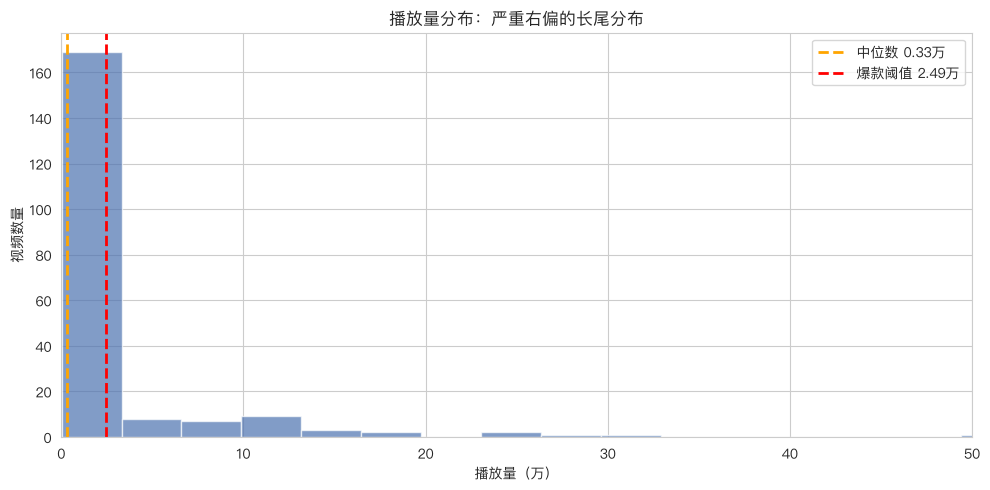

In [7]:
# 播放量分位数分布
print("=== 播放量分位数分布（单位：万）===")
for q in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]:
    print(f"{int(q*100)}分位（前{int((1-q)*100)}%）：{df_clean['播放量'].quantile(q)/10000:.2f} 万")

# 定义爆款：前20%
threshold = df_clean['播放量'].quantile(0.8)
df_clean['是否爆款'] = np.where(df_clean['播放量'] >= threshold, '爆款', '普通')
print(f"\n爆款阈值：播放量 >= {threshold/10000:.2f} 万")
print(df_clean['是否爆款'].value_counts())

# 播放量分布直方图
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['播放量'] / 10000, bins=50, color='#4C72B0', alpha=0.7, edgecolor='white')
ax.axvline(df_clean['播放量'].median() / 10000, color='orange', linestyle='--', linewidth=2, label=f"中位数 {df_clean['播放量'].median()/10000:.2f}万")
ax.axvline(threshold / 10000, color='red', linestyle='--', linewidth=2, label=f"爆款阈值 {threshold/10000:.2f}万")
ax.set_xlabel('播放量（万）')
ax.set_ylabel('视频数量')
ax.set_title('播放量分布：严重右偏的长尾分布')
ax.legend()
ax.set_xlim(0, 50)  # 限制x轴范围，让主体分布更清晰
plt.tight_layout()
plt.show()


> **分析结论**：播放量呈典型的**长尾右偏分布**——中位数仅0.33万，均值4.67万（被爆款拉高14倍），最大值达164.53万。极少数爆款拉动了整体均值，这验证了用分位数法（而非均值）定义爆款的合理性。本项目以播放量前20%（≥2.49万）为爆款阈值，共42条爆款、165条普通视频。


In [9]:
# TOP10爆款
print("=== TOP10 爆款视频 ===")
top10 = df_clean.nlargest(10, '播放量')[['作品名称', '发布时间', '体裁', '播放量', '完播率', '点赞量', '粉丝增量']].copy()
top10.insert(4, '播放量(万)', (top10['播放量'] / 10000).round(2))
display(top10)
df_clean.to_pickle('douyin_labeled.pkl')


=== TOP10 爆款视频 ===


,作品名称,发布时间,体裁,播放量,播放量(万),完播率,点赞量,粉丝增量
206,30岁要存到100万#Jack要加油 #财务自由 ...,2026-03-13 15:01:51,1-3min视频,1645319,164.53,0.062742,63704,1088
134,存钱实操!#Jack要加油 #存钱 #财务自由 #六年之约,2026-05-25 20:36:03,1min-视频,1216352,121.64,0.105260,17556,234
188,别担心家里人 #jack要加油 #认知 #思维,2026-04-01 10:53:31,1-3min视频,881125,88.11,0.057299,58720,1166
108,月入十万的底层逻辑：时间利用率的杠杆游戏\n \n月...,2026-06-28 00:22:01,5min+视频,742620,74.26,0.061221,47086,3184
174,现在站在你面前的是上海普通家庭出身，高二逆袭中上游2...,2026-04-13 19:42:15,1min-视频,507242,50.72,0.109834,48300,3298
202,不投钱 投时间 #Jack要加油 #做生意 #认知,2026-03-19 10:35:55,3-5min视频,299846,29.98,0.036469,6813,166
204,人生成功公式 #Jack要加油 #认知 #自我,2026-03-17 11:31:35,3-5min视频,278793,27.88,0.054948,17311,391
187,积累工作经验 #Jack要加油 #认知 #思维 #工作,2026-04-02 09:57:27,1min-视频,254639,25.46,0.136494,8943,200
57,Jack 讲述自己为什么看好年轻创作者 Q：学历不高...,2026-09-01 12:36:34,1-3min视频,248877,24.89,0.016320,3890,424
126,Jack给粉丝关于投资一条且仅有的一条建议 #Jac...,2026-06-03 17:52:43,1-3min视频,190669,19.07,0.083786,3714,153


## 第4步：爆款vs普通视频核心指标对比

### 分析框架：先留人，后转化

| 组别 | 指标 | 业务含义 |
|------|------|---------|
| **留人指标** | 完播率、5s完播率、2s跳出率、封面点击率、平均播放时长 | 【行业认知】用户点进来后留不留，决定流量池层级 |
| **转化指标** | 点赞率、评论率、转发率、收藏率、粉播比 | 【行业认知】用户认不认内容价值，决定传播与涨粉 |

**同时计算均值和中位数**：均值反映整体水平，中位数不受极端值影响更稳健，两者对照可以判断差异是否由少数极端值驱动。


=== 播放量对比（单位：万）===


,均值(万),中位数(万),最大值(万)
是否爆款,,,
普通,0.40,0.21,2.41
爆款,21.43,10.48,164.53



=== 【留人指标】爆款组 vs 普通组（均值）===


,普通组,爆款组,倍数
5s完播率,0.3884,0.5051,1.3005
平均播放时长,25.6790,27.1887,1.0588
完播率,0.0836,0.0825,0.9877
2s跳出率,0.4055,0.3202,0.7897
封面点击率,0.3297,0.2407,0.7301


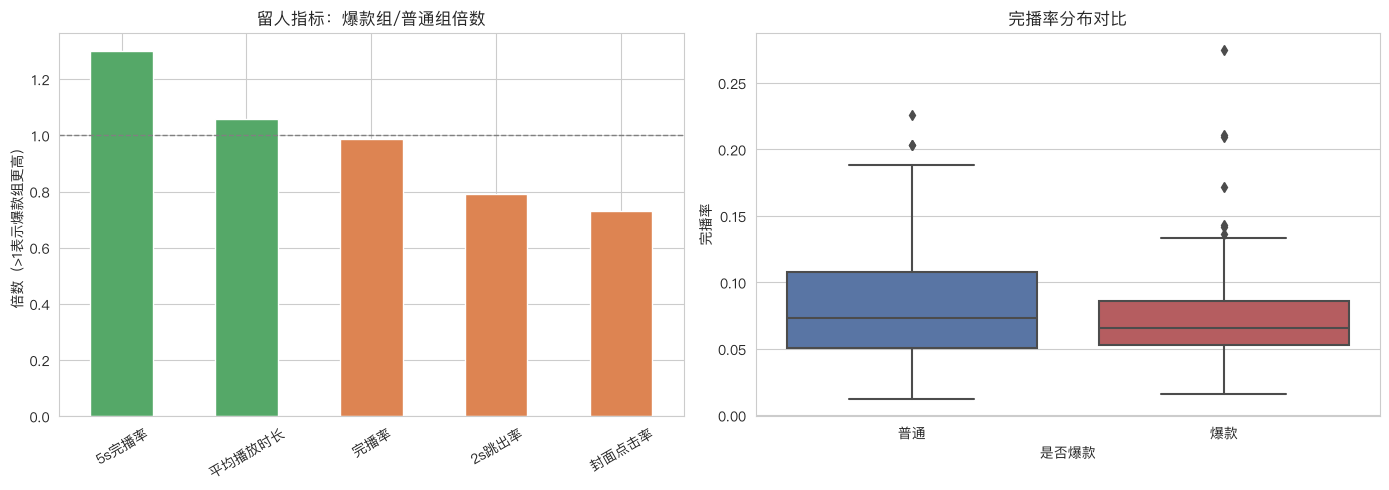

In [11]:
retention_cols = ['完播率', '5s完播率', '2s跳出率', '平均播放时长', '封面点击率']
conversion_cols = ['点赞率', '评论率', '转发率', '收藏率', '粉播比']

# 播放量对比
print("=== 播放量对比（单位：万）===")
play_compare = df_clean.groupby('是否爆款')['播放量'].agg(['mean', 'median', 'max']) / 10000
play_compare.columns = ['均值(万)', '中位数(万)', '最大值(万)']
display(play_compare.round(2))

# ===== 留人指标组对比 =====
print("\n=== 【留人指标】爆款组 vs 普通组（均值）===")
ret_mean = df_clean.groupby('是否爆款')[retention_cols].mean().T
ret_mean.columns = ['普通组', '爆款组']
ret_mean['倍数'] = ret_mean['爆款组'] / ret_mean['普通组']
ret_mean = ret_mean.sort_values('倍数', ascending=False)
display(ret_mean.round(4))

# 留人指标可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：留人指标倍数对比
ret_mean['倍数'].plot(kind='bar', ax=axes[0], color=['#DD8452' if x < 1 else '#55A868' for x in ret_mean['倍数']])
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('留人指标：爆款组/普通组倍数')
axes[0].set_ylabel('倍数（>1表示爆款组更高）')
axes[0].tick_params(axis='x', rotation=30)

# 右图：完播率分布箱线图
sns.boxplot(data=df_clean, x='是否爆款', y='完播率', ax=axes[1], palette=['#4C72B0', '#C44E52'], order=['普通', '爆款'])
axes[1].set_title('完播率分布对比')
plt.tight_layout()
plt.show()


> **分析结论**：
> 1. 留人指标中，**5s完播率**的爆款/普通倍数最高（1.30倍），爆款组50.5% vs 普通组38.8%，是区分爆款的关键留人指标
> 2. **2s跳出率**倍数0.79，爆款组（32.0%）比普通组（40.6%）低8.6个百分点，【行业认知】跳出率越低越好（指标方向为业务常识）
> 3. 值得注意：**完播率几乎无差异**（0.99倍），爆款组8.25% vs 普通组8.36%，说明整体完播率不是区分因素，前5秒留存才是
> 4. 封面点击率爆款组反而更低（0.73倍），可能因为爆款视频被推到更泛的流量池，点击精准度下降
> 5. 从箱线图看，爆款组5s完播率的中位数和分布明显高于普通组


=== 【转化指标】爆款组 vs 普通组（均值）===


,普通组,爆款组,倍数
评论率,0.0013,0.0025,1.8743
转发率,0.0042,0.0070,1.6777
粉播比,0.0010,0.0013,1.3027
收藏率,0.0161,0.0156,0.9697
点赞率,0.0522,0.0443,0.8497


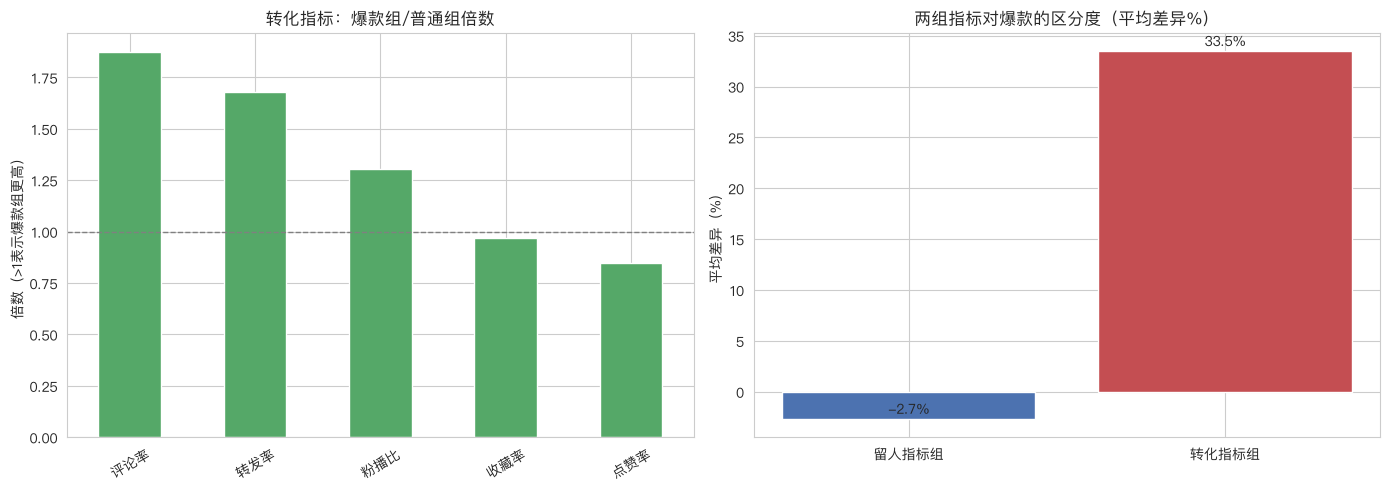

留人指标组区分度：-2.7%
转化指标组区分度：33.5%


In [15]:
# ===== 转化指标组对比 =====
print("=== 【转化指标】爆款组 vs 普通组（均值）===")
conv_mean = df_clean.groupby('是否爆款')[conversion_cols].mean().T
conv_mean.columns = ['普通组', '爆款组']
conv_mean['倍数'] = conv_mean['爆款组'] / conv_mean['普通组']
conv_mean = conv_mean.sort_values('倍数', ascending=False)
display(conv_mean.round(4))

# 转化指标可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conv_mean['倍数'].plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('转化指标：爆款组/普通组倍数')
axes[0].set_ylabel('倍数（>1表示爆款组更高）')
axes[0].tick_params(axis='x', rotation=30)

# 两组区分度对比
ret_diff = (ret_mean['倍数'].abs().mean() - 1) * 100
conv_diff = (conv_mean['倍数'].abs().mean() - 1) * 100
axes[1].bar(['留人指标组', '转化指标组'], [ret_diff, conv_diff], color=['#4C72B0', '#C44E52'])
axes[1].set_title('两组指标对爆款的区分度（平均差异%）')
axes[1].set_ylabel('平均差异（%）')
for i, v in enumerate([ret_diff, conv_diff]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

print(f"留人指标组区分度：{ret_diff:.1f}%")
print(f"转化指标组区分度：{conv_diff:.1f}%")


> **分析结论**：
> 1. 转化指标中，**评论率**的爆款/普通倍数最高（1.87倍），爆款组0.246% vs 普通组0.132%，但该差异统计不显著（见下方矛盾标注）
> 2. **转发率**次之（1.68倍），爆款组0.705% vs 普通组0.420%，【行业认知】转发在抖音算法中被认为权重较高（此为行业通用认知，非本数据结论）
>
> ⚠️ **需要留意（结论暂不锁定）**：评论率分组差异最大（1.87倍），但斯皮尔曼相关性不显著（r=0.057, p=0.418）、曼-惠特尼U检验同样不显著（p=0.142）。原因：分组对比看的是两组均值，爆款组中少数高评论视频拉高了均值；相关性看的是连续变量的单调关系。这说明"评论率高"与"播放量高"之间没有简单直接的对应。**但评论率的作用不能就此否定**——它与其他指标相关性很低、可能提供独特信息，在第6步控制留人等变量后，会看到它显著的"净效应"，届时再下最终结论。
> 3. **粉播比**1.30倍，爆款组0.127% vs 普通组0.097%，爆款不仅带播放更能带涨粉
> 4. 反直觉发现：**点赞率爆款组反而更低**（0.85倍），可能因为爆款被推到泛流量池，用户点赞意愿低于精准粉丝
> 5. 两组对比：转化指标组区分度（33.5%）**高于**留人指标组（-2.7%），说明本账号爆款的核心差异在转化阶段


### 4.1 按体裁分析爆款率

**分析目的**：不同视频时长的爆款概率差异，直接指导内容制作的时长选择。


,视频总数,爆款数,平均播放量万,平均完播率,爆款率
体裁,,,,,
1min-视频,33,8,8.0341,0.1346,0.2424
3-5min视频,47,11,3.3359,0.0743,0.2340
1-3min视频,84,16,4.7178,0.0807,0.1905
5min+视频,43,7,3.4298,0.0592,0.1628


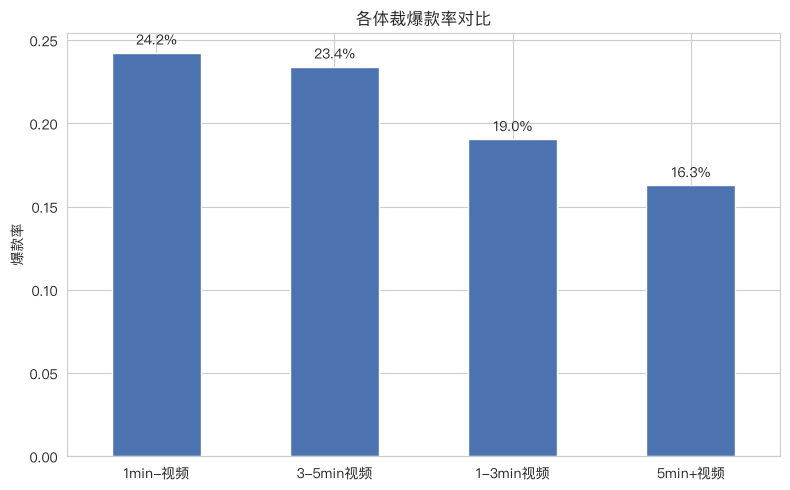

In [21]:
genre_stats = df_clean.groupby('体裁').agg(
    视频总数=('播放量', 'count'),
    爆款数=('是否爆款', lambda x: (x == '爆款').sum()),
    平均播放量万=('播放量', lambda x: x.mean()/10000),
    平均完播率=('完播率', 'mean')
)
genre_stats['爆款率'] = genre_stats['爆款数'] / genre_stats['视频总数']
genre_stats = genre_stats.sort_values('爆款率', ascending=False)
display(genre_stats.round(4))

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
genre_stats['爆款率'].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('各体裁爆款率对比')
ax.set_ylabel('爆款率')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(genre_stats['爆款率']):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()


> **分析结论**：**1分钟以内短视频**爆款率最高（24.2%），平均播放量8.03万也是最高；3-5分钟次之（23.4%）；5分钟以上长视频爆款率最低（16.3%）。最短体裁比最长体裁爆款率高48%。建议后续内容优先控制在1分钟以内，减少5分钟以上长视频制作。


### 4.2 按发布时段分析爆款率


,视频总数,爆款数,平均播放量万,平均完播率,爆款率
发布时段,,,,,
凌晨(0-6点),4,1,18.8867,0.0936,0.2500
上午(6-12点),55,13,5.5092,0.0806,0.2364
下午(12-18点),71,14,4.0898,0.0759,0.1972
晚上(18-24点),77,14,3.8540,0.0917,0.1818


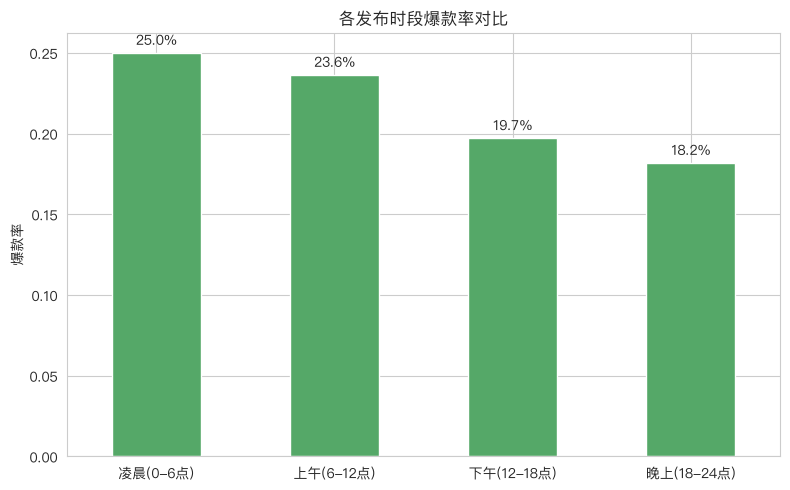

In [26]:
time_stats = df_clean.groupby('发布时段').agg(
    视频总数=('播放量', 'count'),
    爆款数=('是否爆款', lambda x: (x == '爆款').sum()),
    平均播放量万=('播放量', lambda x: x.mean()/10000),
    平均完播率=('完播率', 'mean')
)
time_stats['爆款率'] = time_stats['爆款数'] / time_stats['视频总数']
time_stats = time_stats.sort_values('爆款率', ascending=False)
display(time_stats.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
time_stats['爆款率'].plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('各发布时段爆款率对比')
ax.set_ylabel('爆款率')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(time_stats['爆款率']):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()


> **分析结论**：在样本充足的三个时段中（上午55条、下午71条、晚上77条），**上午（6-12点）**发布的视频爆款率最高（23.6%），下午次之（19.7%），晚上最低（18.2%）。凌晨仅4条样本（1条爆款），样本量不足，其25%爆款率和18.89万平均播放量由单条爆款驱动，不具统计代表性，不纳入结论。建议固定在上午时段发布，避开晚上竞争最激烈的时段。


### 为什么要做相关性分析和显著性检验？

**相关性分析**：量化两个变量之间的关系强度和方向。比如"5s完播率越高，播放量是不是也越高"？相关系数r接近1说明强正相关，接近-1说明强负相关，接近0说明没关系。

**显著性检验**：判断这个关系是真实存在的还是偶然巧合。比如抛硬币10次有7次正面，不能说硬币有问题（样本太少，可能是运气）；但抛1000次有700次正面，就可以确定硬币有问题。p值就是回答"这个结果偶然出现的概率有多大"：p<0.05说明偶然概率小于5%，统计上显著；p>0.05说明可能只是巧合。

**为什么本项目需要两者结合**：光看"爆款组5s完播率比普通组高30%"，无法判断这是真关系还是42条爆款碰巧凑出来的。相关性分析（r=0.734）说明关系很强，显著性检验（p<0.001）说明偶然概率小于0.1%，两者交叉验证，结论才站得住。

---

## 第5步：相关性分析与显著性检验

### 方法论：为什么用斯皮尔曼相关而不是皮尔逊相关？

| 对比维度 | 皮尔逊相关 | 斯皮尔曼相关 |
|---------|-----------|-------------|
| 数据要求 | 变量呈正态分布、线性关系 | 无分布要求，基于秩次 |
| 异常值敏感度 | 高，极端值会严重扭曲结果 | 低，对异常值稳健 |
| 适用场景 | 身高体重等正态连续变量 | 播放量、收入等偏态数据 |

**本项目选择斯皮尔曼的原因**：播放量呈严重右偏分布（前已验证），互动率指标也偏态，不满足皮尔逊的正态性假设。斯皮尔曼通过秩次计算，能稳健捕捉单调关系，且p值可靠。


=== 各特征与播放量的斯皮尔曼相关性（按绝对值排序）===


,特征,组别,相关系数,p值,显著性
2,2s跳出率,留人,-0.7550,0.0000,***
1,5s完播率,留人,0.7341,0.0000,***
7,转发率,转化,0.5625,0.0000,***
8,收藏率,转化,0.2351,0.0006,***
4,封面点击率,留人,-0.1568,0.1399,不显著
9,粉播比,转化,0.1399,0.0444,*
0,完播率,留人,0.1297,0.0625,不显著
3,平均播放时长,留人,0.1149,0.0992,不显著
5,点赞率,转化,-0.0780,0.2638,不显著
6,评论率,转化,0.0566,0.4182,不显著


注：*** p<0.001, ** p<0.01, * p<0.05


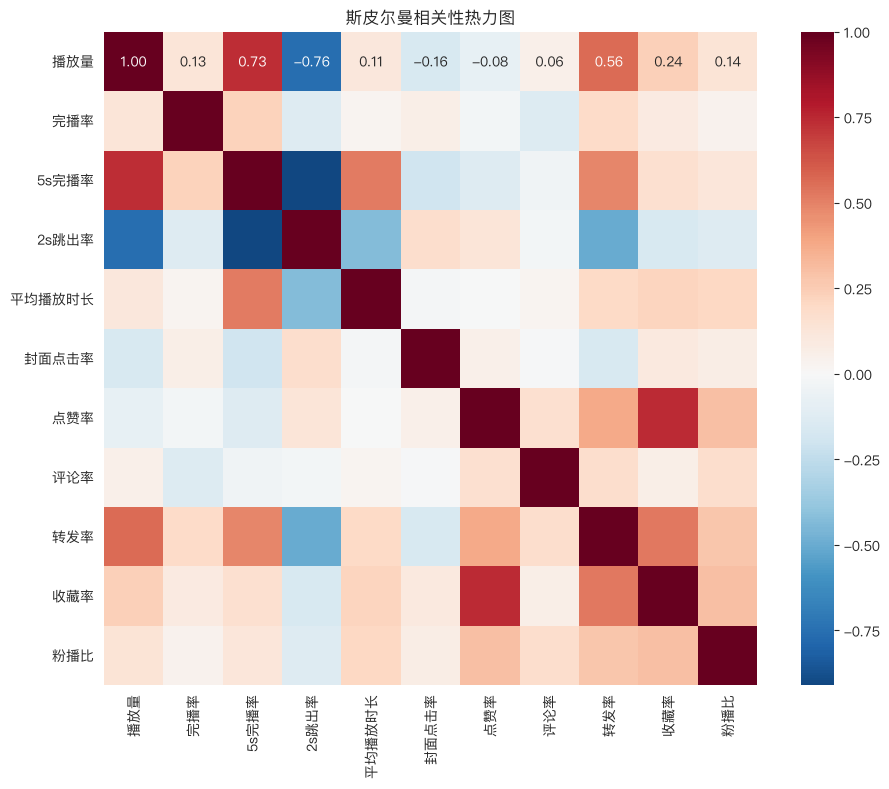

In [30]:
from scipy import stats

feature_cols = retention_cols + conversion_cols + ['发布小时']
results = []
for col in feature_cols:
    valid = df_clean[[col, '播放量']].dropna()
    if len(valid) > 10:
        corr, p_value = stats.spearmanr(valid[col], valid['播放量'])
        sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else '不显著'))
        group = '留人' if col in retention_cols else ('转化' if col in conversion_cols else '其他')
        results.append({'特征': col, '组别': group, '相关系数': corr, 'p值': p_value, '显著性': sig})

corr_df = pd.DataFrame(results).sort_values('相关系数', key=abs, ascending=False)
print("=== 各特征与播放量的斯皮尔曼相关性（按绝对值排序）===")
display(corr_df.round(4))
print("注：*** p<0.001, ** p<0.01, * p<0.05")

# 相关性热力图
all_corr_cols = ['播放量'] + retention_cols + conversion_cols
corr_matrix = df_clean[all_corr_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('斯皮尔曼相关性热力图')
plt.tight_layout()
plt.show()


> **分析结论**：
> 1. 与播放量相关性最高的特征是**2s跳出率**（r=-0.755, p<0.001）和**5s完播率**（r=0.734, p<0.001），均极显著——前2秒不划走、前5秒能留住，是爆款的核心前提
> 2. 转化指标中**转发率**相关性最高（r=0.563, p<0.001），其次是收藏率（r=0.235, p<0.001）
> 3. **完播率整体不显著**（r=0.130, p=0.063），再次验证了"整体完播率不重要，前5秒留存才重要"
> 4. 点赞率、评论率、封面点击率、平均播放时长均不显著，与播放量无统计上的显著关联
> 5. 粉播比边缘显著（r=0.140, p=0.044），爆款有一定涨粉效应


### 5.1 曼-惠特尼U检验：爆款组与普通组的差异显著性

### 方法论：为什么用曼-惠特尼U检验而不是t检验？

| 对比维度 | 独立样本t检验 | 曼-惠特尼U检验 |
|---------|-------------|---------------|
| 数据要求 | 两组均正态分布、方差齐性 | 无分布要求（非参数检验） |
| 样本量要求 | 通常需要n>30且正态 | 小样本也适用 |
| 比较内容 | 均值差异 | 分布/秩次差异 |

**本项目选择曼-惠特尼U的原因**：爆款组仅约40条样本，且播放量、互动率等指标均偏态分布，不满足t检验的正态性假设。曼-惠特尼U通过秩和判断两组是否来自同一分布，是偏态数据两组比较的标准方法。


In [34]:
def run_mwu(cols):
    test_results = []
    for col in cols:
        g_viral = df_clean[df_clean['是否爆款'] == '爆款'][col].dropna()
        g_normal = df_clean[df_clean['是否爆款'] == '普通'][col].dropna()
        if len(g_viral) > 5 and len(g_normal) > 5:
            stat, p_value = stats.mannwhitneyu(g_viral, g_normal, alternative='two-sided')
            sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else '不显著'))
            test_results.append({'指标': col, '爆款中位数': g_viral.median(), '普通中位数': g_normal.median(), 'p值': p_value, '显著性': sig})
    return pd.DataFrame(test_results).sort_values('p值')

print("=== 【留人指标】曼-惠特尼U检验 ===")
display(run_mwu(retention_cols).round(4))
print("\n=== 【转化指标】曼-惠特尼U检验 ===")
display(run_mwu(conversion_cols).round(4))


=== 【留人指标】曼-惠特尼U检验 ===


,指标,爆款中位数,普通中位数,p值,显著性
1,5s完播率,0.5075,0.3949,0.0000,***
2,2s跳出率,0.3143,0.3964,0.0000,***
4,封面点击率,0.1867,0.2821,0.0510,不显著
3,平均播放时长,24.1956,20.7533,0.2479,不显著
0,完播率,0.0656,0.0733,0.4540,不显著



=== 【转化指标】曼-惠特尼U检验 ===


,指标,爆款中位数,普通中位数,p值,显著性
2,转发率,0.0068,0.0039,0.0000,***
0,点赞率,0.0388,0.0549,0.0140,*
1,评论率,0.0010,0.0008,0.1424,不显著
4,粉播比,0.0007,0.0007,0.1657,不显著
3,收藏率,0.0158,0.0156,0.5925,不显著


> **分析结论**：
> 1. 留人指标中，**5s完播率**和**2s跳出率**在爆款组与普通组间存在极显著差异（均p<0.001），其余留人指标不显著
> 2. 转化指标中，**转发率**极显著（p<0.001），**点赞率**显著（p=0.014），评论率/收藏率/粉播比不显著
> 3. 结合相关性分析，**5s完播率、2s跳出率、转发率**是既显著相关又组间差异显著的三大核心因素
> 4. 封面点击率边缘显著（p=0.051），有一定区分度但不够稳定


## 第6步：逻辑回归特征重要性建模

### 方法论：为什么用逻辑回归？

1. **因变量是二分类**（爆款=1，普通=0），逻辑回归是广义线性模型中处理二分类的标准方法
2. **系数可解释**：标准化后的回归系数直接反映各特征对爆款概率的影响方向和大小，适合业务解读
3. **相比树模型的优势**：随机森林/XGBoost虽预测力可能更强，但特征重要性是黑盒，无法说明影响方向；逻辑回归系数正负明确，面试时能讲清"每个因素怎么影响爆款"
4. **标准化处理**：各特征量纲不同（完播率是0-1，播放时长是几十秒），标准化后系数才可直接比较


建模样本数：207 条
5折交叉验证准确率：0.8495 +/- 0.0704

=== 逻辑回归特征重要性（标准化系数）===


,特征,组别,回归系数,影响方向,系数绝对值
9,发布小时,其他,-0.0173,负向,0.0173
8,粉播比,转化,0.2073,正向,0.2073
7,收藏率,转化,0.3564,正向,0.3564
0,完播率,留人,-0.4197,负向,0.4197
6,转发率,转化,0.4266,正向,0.4266
2,2s跳出率,留人,-0.8219,负向,0.8219
4,点赞率,转化,-0.8547,负向,0.8547
3,平均播放时长,留人,-0.9184,负向,0.9184
5,评论率,转化,0.9371,正向,0.9371
1,5s完播率,留人,1.6686,正向,1.6686


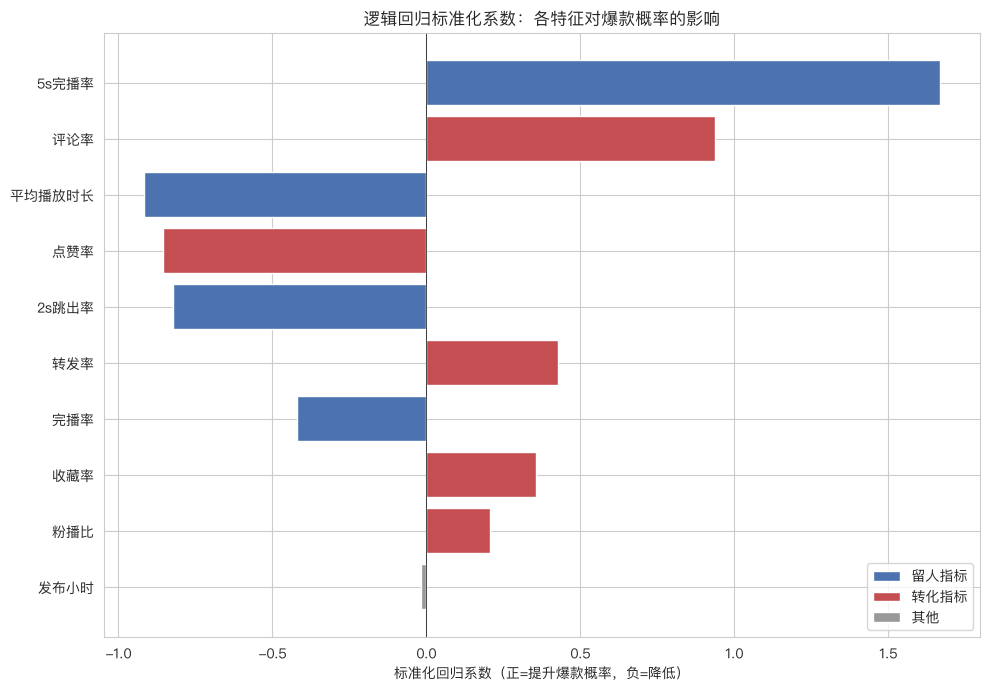


留人指标组综合影响力：3.8286
转化指标组综合影响力：2.7821


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

model_cols = ['完播率', '5s完播率', '2s跳出率', '平均播放时长'] + conversion_cols + ['发布小时']
df_model = df_clean[model_cols + ['是否爆款']].dropna()
print(f"建模样本数：{len(df_model)} 条")

X = df_model[model_cols]
y = (df_model['是否爆款'] == '爆款').astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)

cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
print(f"5折交叉验证准确率：{cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# 特征重要性
importance = pd.DataFrame({
    '特征': model_cols,
    '回归系数': model.coef_[0],
    '组别': ['留人' if c in retention_cols else ('转化' if c in conversion_cols else '其他') for c in model_cols]
})
importance['影响方向'] = importance['回归系数'].apply(lambda x: '正向' if x > 0 else '负向')
importance['系数绝对值'] = importance['回归系数'].abs()
importance = importance.sort_values('系数绝对值', ascending=True)

print("\n=== 逻辑回归特征重要性（标准化系数）===")
display(importance[['特征', '组别', '回归系数', '影响方向', '系数绝对值']].round(4))

# 可视化：水平条形图
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'留人': '#4C72B0', '转化': '#C44E52', '其他': '#999999'}
bar_colors = [colors[g] for g in importance['组别']]
ax.barh(importance['特征'], importance['回归系数'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('逻辑回归标准化系数：各特征对爆款概率的影响')
ax.set_xlabel('标准化回归系数（正=提升爆款概率，负=降低）')
# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='留人指标'), Patch(facecolor='#C44E52', label='转化指标'), Patch(facecolor='#999999', label='其他')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# 两组综合影响力
ret_power = importance[importance['组别'] == '留人']['系数绝对值'].sum()
conv_power = importance[importance['组别'] == '转化']['系数绝对值'].sum()
print(f"\n留人指标组综合影响力：{ret_power:.4f}")
print(f"转化指标组综合影响力：{conv_power:.4f}")


In [39]:
# ===== 6.1 回归系数的统计显著性检验（statsmodels）=====
# sklearn 只输出系数"大小"，但系数大不等于可信——还需 p 值判断它是否可能只是随机噪声。
# 这里用 statsmodels 拟合【无正则化】逻辑回归（正则化会压缩系数、不适合做显著性推断），输出每个系数的 p 值。
import sys
from statsmodels.discrete.discrete_model import Logit as smLogit

X_with_const = np.column_stack([np.ones(len(X_scaled)), X_scaled])
_orig_stdout = sys.stdout
sm_model = smLogit(y.values, X_with_const).fit(disp=0, maxiter=1000)
sys.stdout = _orig_stdout  # 恢复被 statsmodels 临时重定向的标准输出

sm_params = np.asarray(sm_model.params)
sm_pvals = np.asarray(sm_model.pvalues)
sig_table = pd.DataFrame({
    '特征': ['截距'] + model_cols,
    '系数': sm_params,
    'p值': sm_pvals,
})
sig_table['显著性'] = sig_table['p值'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '不显著')))
print("显著性标准：*** p<0.001, ** p<0.01, * p<0.05")
display(sig_table.round(4))


显著性标准：*** p<0.001, ** p<0.01, * p<0.05


,特征,系数,p值,显著性
0,截距,-2.8766,0.0000,***
1,完播率,-0.5028,0.0537,不显著
2,5s完播率,2.3894,0.0019,**
3,2s跳出率,-0.5549,0.4689,不显著
4,平均播放时长,-1.2297,0.0006,***
5,点赞率,-1.3256,0.0255,*
6,评论率,1.3894,0.0025,**
7,转发率,0.4784,0.1652,不显著
8,收藏率,0.7196,0.1455,不显著
9,粉播比,0.2409,0.3534,不显著


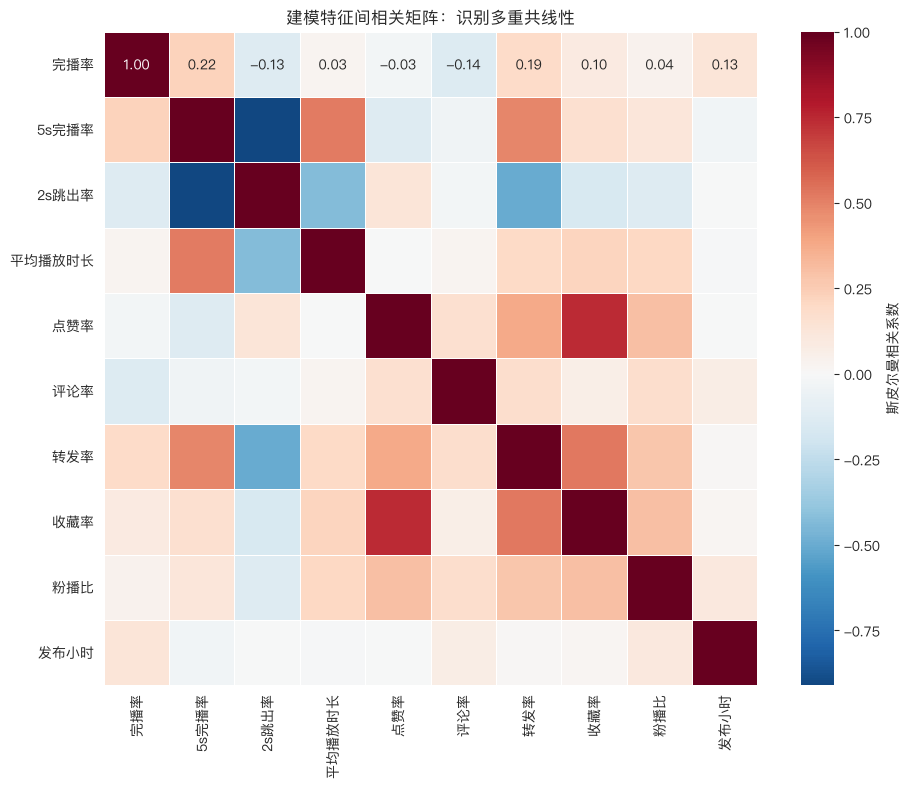

,特征,VIF,共线性判断
1,5s完播率,6.52,偏高(5-10)
2,2s跳出率,5.71,偏高(5-10)
7,收藏率,2.96,正常(<5)
4,点赞率,2.88,正常(<5)
6,转发率,1.82,正常(<5)
3,平均播放时长,1.40,正常(<5)
8,粉播比,1.15,正常(<5)
0,完播率,1.10,正常(<5)
5,评论率,1.08,正常(<5)
9,发布小时,1.06,正常(<5)


In [40]:
# ===== 6.2 多重共线性诊断 =====
# 系数 p 值检验会发现一个反常现象：单变量分析中极强的 2s跳出率、转发率，放进多元回归后 p 值反而不显著。
# 最常见原因是"多重共线性"——特征之间高度相关，导致同一部分效应被多个变量重复计算、系数被分摊而不稳定。

# (1) 特征间斯皮尔曼相关矩阵热力图
fig, ax = plt.subplots(figsize=(10, 8))
feat_corr = X.corr(method='spearman')
sns.heatmap(feat_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': '斯皮尔曼相关系数'})
ax.set_title('建模特征间相关矩阵：识别多重共线性')
plt.tight_layout()
plt.show()

# (2) VIF 方差膨胀因子（VIF>10 为严重共线性，5~10 偏高，<5 正常）
from numpy.linalg import inv
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
vif_values = np.diag(inv(corr_matrix))
vif_table = pd.DataFrame({'特征': model_cols, 'VIF': vif_values})
vif_table['共线性判断'] = vif_table['VIF'].apply(
    lambda v: '严重(>10)' if v > 10 else ('偏高(5-10)' if v > 5 else '正常(<5)'))
vif_table = vif_table.sort_values('VIF', ascending=False)
display(vif_table.round(2))


> **分析结论（综合 sklearn 系数 + statsmodels 显著性 + 共线性诊断）**：
>
> **关于两套系数的说明**：上方 sklearn 系数带 L2 正则化（作用是预测、防止过拟合），系数偏保守；6.1 的 statsmodels 系数无正则化（作用是做显著性推断、给 p 值）。看"影响方向和相对大小"用 sklearn 系数，判断"是否可信"看 statsmodels 的 p 值。
>
> **1. 模型预测能力**：5折交叉验证准确率 **84.95%**，所选特征对爆款有较强区分能力。
>
> **2. 系数 p 值揭示的"真正显著"因素**（6.1 表）：
> - **5s完播率**（p=0.002）、**评论率**（p=0.003）、**平均播放时长**（p<0.001，负向）、**点赞率**（p=0.026，负向）这 4 个系数统计显著；
> - 而单变量分析中极强的 **2s跳出率（p=0.469）、转发率（p=0.165）在多元回归里反而不显著**——原因见第3点共线性。
>
> **3. 共线性诊断是理解上述"反常"的关键**（6.2 图/表）：
> - **5s完播率与2s跳出率相关高达 -0.91**（VIF 分别 6.5 / 5.7，偏高）：它俩几乎是同一件事——前5秒留住了，2s自然不跳出。同时放进模型后，2s跳出率的效应被5s完播率"吸收"，故 p 值不显著。**它俩是"留人"这一个维度的两个观测点，不是两个独立因素。**
> - **转发率**与5s完播率（0.49）、收藏率（0.53）、点赞率（0.37）中度相关：它是内容综合质量的体现，独立效应被这些相关变量分摊，故净效应 p=0.165 不显著，但**不代表转发不重要**（单变量 r=0.563 是铁证）。
>
> **4. 评论率的"净效应"翻案**（呼应第4步的"暂不锁定"）：评论率与其他所有指标相关性都很低（<0.18，VIF 1.1），提供的是**不被任何指标包含的独特信息**。单变量不显著，是因为没考虑"留人"这个前提；**控制留人等变量后，评论率净效应显著为正（p=0.003）**。正确解读：**先得在前5秒留住人，在此基础上评论越多的视频越容易爆**——评论率是"留人达标后的条件助推因素"，而非单纯的"爆款结果"。
>
> ⚠️ **仍需谨慎（相关≠因果）**：以上全部基于观察数据，评论率高也可能与"话题本身有争议性"这类未观测因素有关，"引导评论"的策略是合理尝试，但不能宣称严格因果。
>
> **5. 两处"看似矛盾"的解释**：
>
> ⚠️ **矛盾A（时长）**：分组对比中爆款组平均时长（27.2秒）略高于普通组（25.7秒），但回归中时长系数为负（sklearn -0.92，statsmodels p<0.001）。原因：分组对比未控制其他变量，爆款组少数长视频碰巧爆了拉高均值；控制变量后时长的独立效应明确为负。结合体裁（1min以内爆款率24.2%最高），**短视频更易爆是稳健结论**。
>
> ⚠️ **矛盾B（区分度 vs 影响力）**：分组区分度转化组（33.5%）> 留人组（-2.7%），但回归影响力留人组（3.83）> 转化组（2.78）。两者口径不同、互补成立：**留人决定下限（进不进池），转化决定上限（进池后能推多远）**。
>
> ⚠️ **对"影响力3.83 vs 2.78"的额外修正**：留人组的 3.83 中，5s完播率与2s跳出率高度冗余（r=-0.91），直接相加会**重复计算**同一部分效应，因此 3.83 高估了留人组的独立信息量；转化组内部相关性低、重复计算少。所以两组影响力的真实差距没有数字看起来那么悬殊，但 **5s完播率作为单一最强因素的地位不受影响**。
>
> **6. 发布时间**：发布小时系数接近0（-0.02，p=0.97），控制其他因素后，发布时段对爆款的**直接**影响很小；时段爆款率的差异更多通过"是否影响留人"间接起作用。


## 第7步：总结论与策略建议

### 7.1 爆款驱动因素梯队（按证据强度排序）

综合**分组对比、斯皮尔曼相关、曼-惠特尼U检验、逻辑回归系数p值、共线性诊断**五类分析，按"证据是否稳健"而非单一系数大小排序：

#### 第一梯队：最核心、三方法一致

1. **5s完播率是第一驱动因素**
   - 爆款组50.5% vs 普通组38.8%（高30%）；斯皮尔曼 r=0.734（p<0.001）；曼-惠特尼 p<0.001；逻辑回归净效应 p=0.002
   - 它是**唯一在所有方法中都显著**的因素，且代表了整个"留人"维度（2s跳出率 r=-0.91 与其冗余）

2. **短视频更易爆（时长是稳健负向因素）**
   - 1分钟以内爆款率24.2%最高，5分钟以上仅16.3%；逻辑回归时长净效应 p<0.001（负向）
   - 注意：分组对比中爆款组时长略高是少数长视频拉高均值的假象，控制变量后负向结论明确

#### 第二梯队：强转化信号

3. **转发率是最强的"综合质量"信号**
   - 爆款组0.705% vs 普通组0.420%（高68%）；斯皮尔曼 r=0.563、曼-惠特尼 p<0.001
   - 多元回归净效应不显著（p=0.165）是因为它与留人、收藏、点赞中度相关、效应被分摊，但单变量证据极强，仍是破圈放大器

4. **评论率是"留人达标后"的条件助推因素**
   - 单变量不显著（r=0.057，曼-惠特尼 p=0.142），但控制留人等变量后**净效应显著为正（p=0.003）**
   - 含义：先留得住人，评论多才进一步助推爆款；评论率提供了其他互动指标没有的独特信息
   - （相关≠因果，此为观察数据结论）

#### 负向 / 无效因素

5. **点赞率反直觉为负**：爆款组点赞率更低（0.85倍），曼-惠特尼 p=0.014、回归 p=0.026 均显著负向——高点赞率多为"精准小圈层"视频，难破圈
6. **整体完播率不重要**：爆款与普通几乎无差异（0.99倍，p=0.454），用户不需要看完，前5秒留住即可
7. **发布时段直接影响很小**：上午爆款率23.6%最高（晚上18.2%最低），但控制变量后发布小时净效应 p=0.97，时段更多通过影响留人间接起作用（凌晨仅4条样本不纳入比较）

### 7.2 落地策略（按优先级）

| 优先级 | 阶段 | 策略 | 数据依据 | 量化目标 |
|--------|------|------|---------|---------|
| ★★★ | 留人 | 前2秒制造冲突/悬念，前5秒抛出核心价值 | 5s完播率全方法显著（r=0.734） | 5s完播率提升至50%+ |
| ★★★ | 留人 | 视频时长控制在1分钟以内，减少5min+长视频 | 1min爆款率24.2%，时长净效应p<0.001 | 爆款率提升至24%+ |
| ★★☆ | 转化 | 设计转发钩子（如"@你那个XX的朋友"、实用清单） | 转发率r=0.563，爆款组高68% | 转发率提升至0.7%+ |
| ★★☆ | 转化 | 结尾留争议性/开放性观点引导评论 | 评论率净效应p=0.003（单变量不显著，需先保证留人） | 评论率提升至0.25%+ |
| ★☆☆ | 发布 | 固定上午（6-12点）发布 | 上午爆款率23.6%最高（直接效应弱，凌晨4条不比较） | 提高初始流量通过率 |
| 避免 | — | 不追求高完播率、不刻意求点赞 | 完播率不显著、点赞率显著为负 | 避免策略走偏 |

### 7.3 项目价值

- 基于 **207 条真实视频数据**，以"先留人后转化"框架系统拆解爆款驱动因素
- 运用**分组对比、斯皮尔曼相关、曼-惠特尼U检验、逻辑回归、共线性诊断（VIF）**等多种方法交叉验证，模型预测准确率 85%
- 核心结论：**前5秒留存（而非整体完播率）是第一驱动，转发是综合质量放大器，评论是留人达标后的条件助推**，修正了"完播率最重要""评论多=会爆"等想当然的认知
- 主动识别并解释了多重共线性（5s与2s冗余）、净效应（评论率翻案）等统计陷阱，保证结论可信
- 输出了可量化、可执行、带优先级的内容生产策略，为后续选题与制作提供数据驱动的决策依据
